# Neural Style Transfer using VGG19

This notebook demonstrates:
- Extracting content and style features
- Using Gram Matrix for style representation
- Optimizing an image using gradient descent

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [3]:
def load_image(path):
    img = load_img(path, target_size=(224, 224))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return tf.keras.applications.vgg19.preprocess_input(img)

content_image = load_image("content.jpg")
style_image = load_image("style.jpg")

In [4]:
vgg = VGG19(weights='imagenet', include_top=False)

In [5]:
content_layers = ['block5_conv2']
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1']

outputs = [vgg.get_layer(name).output for name in content_layers + style_layers]
model = tf.keras.Model(vgg.input, outputs)

In [6]:
def gram_matrix(x):
    x = tf.reshape(x, (-1, x.shape[-1]))
    return tf.matmul(x, x, transpose_a=True)

In [7]:
def compute_loss(generated):
    outputs = model(generated)
    
    content_output = outputs[0]
    style_outputs = outputs[1:]

    # Content Loss
    content_loss = tf.reduce_mean((content_output - model(content_image)[0])**2)

    # Style Loss
    style_loss = 0
    for i, style_output in enumerate(style_outputs):
        gram_gen = gram_matrix(style_output)
        gram_style = gram_matrix(model(style_image)[i+1])
        style_loss += tf.reduce_mean((gram_gen - gram_style)**2)

    total_loss = content_loss + 1e-4 * style_loss
    return total_loss

In [8]:
generated = tf.Variable(content_image, dtype=tf.float32)
optimizer = tf.optimizers.Adam(learning_rate=0.01)

for i in range(100):
    with tf.GradientTape() as tape:
        loss = compute_loss(generated)
    
    grads = tape.gradient(loss, generated)
    optimizer.apply_gradients([(grads, generated)])

    if i % 10 == 0:
        print(f"Iteration {i}, Loss: {loss}")

Iteration 0, Loss: 37098316890112.0
Iteration 10, Loss: 36938509713408.0
Iteration 20, Loss: 36778400546816.0
Iteration 30, Loss: 36617951641600.0
Iteration 40, Loss: 36457125249024.0
Iteration 50, Loss: 36295887814656.0
Iteration 60, Loss: 36134323224576.0
Iteration 70, Loss: 35972397924352.0
Iteration 80, Loss: 35810120302592.0
Iteration 90, Loss: 35647549079552.0


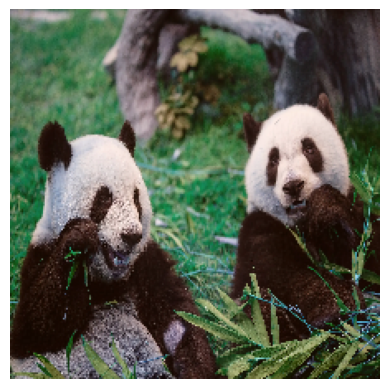

In [9]:
def deprocess(img):
    img = img.reshape((224, 224, 3))
    img = img - np.min(img)
    img = img / np.max(img)
    return img

plt.imshow(deprocess(generated.numpy()))
plt.axis('off')
plt.show()

## Explanation

### 🔹 Neural Style Transfer (NST)
Combines:
- Content of one image
- Style of another image

### 🔹 Key Concepts

- **Content Loss** → Preserves structure of original image
- **Style Loss** → Uses Gram Matrix to capture texture
- **Optimization** → Updates pixels to minimize total loss

### 🔹 Model Used
- VGG19 pretrained on ImageNet

### 🔹 Output
A stylized image blending both inputs